In [1]:
from rdkit import Chem

import pandas as pd

from chembl_structure_pipeline import standardizer

from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from rdkit.Chem import Lipinski
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Descriptors

import seaborn as sns

[12:07:33] Initializing Normalizer


In [2]:
suppl = Chem.SDMolSupplier('../data/drugbank.sdf')
drugbank_df = pd.DataFrame({"source": "drugbank", "mol": mol, "id": mol.GetProp("DATABASE_ID")} for mol in suppl if mol)
drugbank_df.set_index("id", inplace=True)
drugbank_df

,source,mol
id,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...
...,...,...
DB13154,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118DD5...
DB13155,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118DD5...
DB13156,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118DD5...


In [3]:
zinc_df = pd.read_csv("../data/zinc_random_structures.txt", delimiter=" ")
zinc_df.rename(columns={"zincid": "id"}, inplace=True)
zinc_df.set_index("id", inplace=True)
zinc_df['source'] = 'zinc'
zinc_df['mol'] = zinc_df['SMILES'].apply(lambda x: Chem.MolFromSmiles(x))
zinc_df.drop(columns=['tranche', 'SMILES'], inplace=True)
zinc_df

,source,mol
id,,
ZINCtA000001eUS8,zinc,<rdkit.Chem.rdchem.Mol object at 0x00000118DD5...
ZINCpo00001BLwat,zinc,<rdkit.Chem.rdchem.Mol object at 0x00000118DD5...
ZINCtz000004JjrO,zinc,<rdkit.Chem.rdchem.Mol object at 0x00000118DD5...
ZINCsN000009NpXg,zinc,<rdkit.Chem.rdchem.Mol object at 0x00000118DD5...
ZINCsN000009NsBY,zinc,<rdkit.Chem.rdchem.Mol object at 0x00000118DD5...
...,...,...
ZINCrn00001eRwYj,zinc,<rdkit.Chem.rdchem.Mol object at 0x00000118E54...
ZINCsN000009Nrlo,zinc,<rdkit.Chem.rdchem.Mol object at 0x00000118E54...
ZINCtB00000oxE6f,zinc,<rdkit.Chem.rdchem.Mol object at 0x00000118E54...


In [4]:
mtor_df = pd.read_csv("../data/chembl_mtor_ic50.csv", delimiter=";", usecols=["Molecule ChEMBL ID", "Smiles"])
mtor_df.rename(columns={"Molecule ChEMBL ID": "id"}, inplace=True)
mtor_df.set_index("id", inplace=True)
mtor_df['source'] = 'chembl'
mtor_df['mol'] = mtor_df['Smiles'].apply(lambda x: Chem.MolFromSmiles(x))
mtor_df.drop(columns=['Smiles'], inplace=True)
mtor_df

,source,mol
id,,
CHEMBL1773577,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118D85...
CHEMBL1773561,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118D85...
CHEMBL1773077,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118D85...
CHEMBL1773580,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118D85...
CHEMBL1773578,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118D85...
...,...,...
CHEMBL4287809,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118E55...
CHEMBL4280265,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118E55...
CHEMBL4246563,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118E55...


In [5]:
structures = pd.concat([drugbank_df, zinc_df, mtor_df])
structures

,source,mol
id,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...
...,...,...
CHEMBL4287809,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118E55...
CHEMBL4280265,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118E55...
CHEMBL4246563,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118E55...


In [6]:
structures['mol'] = structures['mol'].apply(lambda x: standardizer.standardize_mol(x))
structures

,source,mol
id,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118CEF...
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...
...,...,...
CHEMBL4287809,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118FF4...
CHEMBL4280265,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118FF4...
CHEMBL4246563,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118FF4...


In [7]:
structures['HBA'] = structures['mol'].apply(lambda x: Lipinski.NumHAcceptors(x))
structures['HBD'] = structures['mol'].apply(lambda x: Lipinski.NumHDonors(x))
structures['LogP'] = structures['mol'].apply(lambda x: Descriptors.MolLogP(x))
structures['MW'] = structures['mol'].apply(lambda x: rdMolDescriptors.CalcExactMolWt(x))
structures

,source,mol,HBA,HBD,LogP,MW
id,,,,,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118CEF...,29,28,-8.11643,2178.985813
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...,16,17,-3.10570,1268.641439
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...,15,14,-4.13203,1068.426955
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...,16,17,-0.50613,1429.669818
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...,12,5,3.26900,1201.841368
...,...,...,...,...,...,...
CHEMBL4287809,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118FF4...,6,1,2.70500,426.079804
CHEMBL4280265,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118FF4...,5,1,3.48890,448.020845
CHEMBL4246563,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118FF4...,4,1,4.92340,407.126991


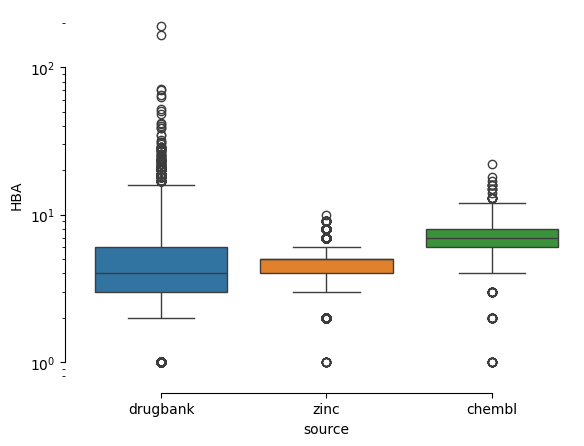

In [8]:
sns.boxplot(x="source", y="HBA", hue="source", data=structures, log_scale=True)
sns.despine(offset=10, trim=True)

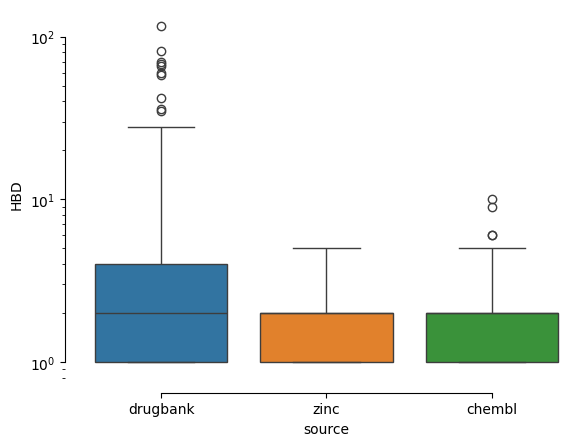

In [9]:
sns.boxplot(x="source", y="HBD", hue="source", data=structures, log_scale=True)
sns.despine(offset=10, trim=True)

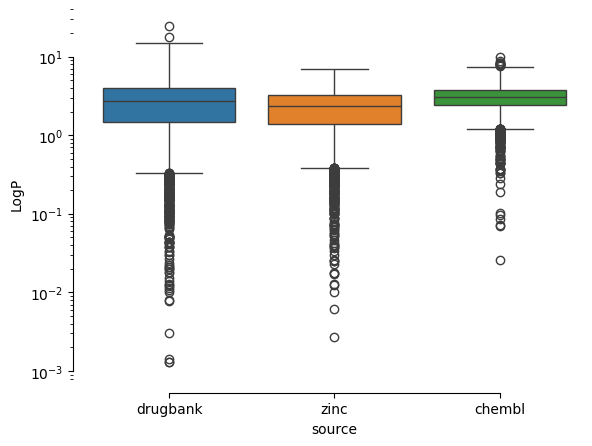

In [10]:
sns.boxplot(x="source", y="LogP", hue="source", data=structures, log_scale=True)
sns.despine(offset=10, trim=True)

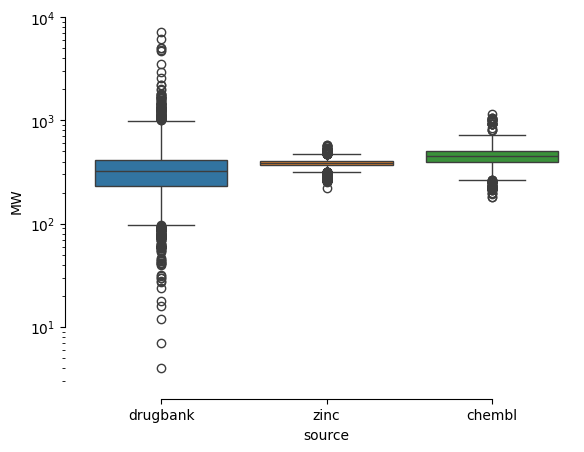

In [11]:
sns.boxplot(x="source", y="MW", hue="source", data=structures, log_scale=True)
sns.despine(offset=10, trim=True)

In [13]:
structures.to_csv('../data/standardized_structures.csv', columns=['source', 'SMILES'])

In [12]:
structures['SMILES'] = structures['mol'].apply(lambda x: Chem.MolToSmiles(x))
structures

,source,mol,HBA,HBD,LogP,MW,SMILES
id,,,,,,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118CEF...,29,28,-8.11643,2178.985813,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...,16,17,-3.10570,1268.641439,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...,15,14,-4.13203,1068.426955,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]1...
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...,16,17,-0.50613,1429.669818,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...,12,5,3.26900,1201.841368,C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...
...,...,...,...,...,...,...,...
CHEMBL4287809,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118FF4...,6,1,2.70500,426.079804,COc1ncc(-c2ccc3nccc(=O)n3c2)cc1NS(=O)(=O)c1ccc...
CHEMBL4280265,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118FF4...,5,1,3.48890,448.020845,O=c1ccnc2ccc(-c3cnc(Cl)c(NS(=O)(=O)c4ccc(F)cc4...
CHEMBL4246563,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118FF4...,4,1,4.92340,407.126991,C=CC(=O)Nc1ccc(-n2c(=O)ccc3oc4ccc(-c5cccnc5)cc...


In [19]:
long_structures = structures.melt(["source"],["HBA", "HBD", "LogP", "MW"])

In [17]:
long_structures

,source,variable,value
0,drugbank,HBA,29.00000
1,drugbank,HBA,16.00000
2,drugbank,HBA,15.00000
3,drugbank,HBA,16.00000
4,drugbank,HBA,12.00000
...,...,...,...
56683,chembl,LogP,2.70500
56684,chembl,LogP,3.48890
56685,chembl,LogP,4.92340
56686,chembl,LogP,1.48800


<Axes: xlabel='variable', ylabel='value'>

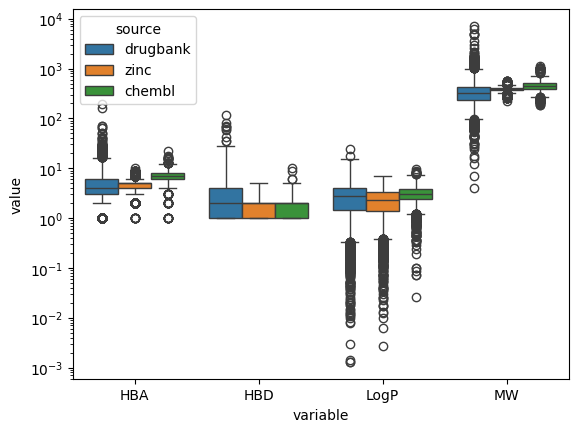

In [20]:
sns.boxplot(x="variable", y="value", hue="source", data=long_structures, log_scale=True)

<Axes: xlabel='HBA', ylabel='HBD'>

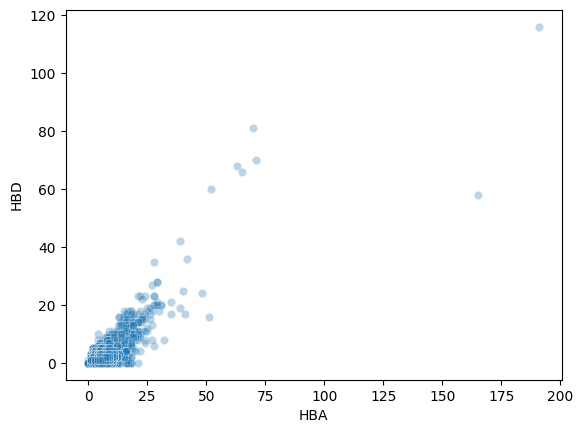

In [26]:
sns.scatterplot(data=structures, x="HBA", y="HBD", alpha=0.3)

In [31]:
structures[structures["source"]=="drugbank"][["HBA", "HBD", "LogP", "MW"]].corr()

,HBA,HBD,LogP,MW
HBA,1.000000,0.828890,-0.490321,0.841642
HBD,0.828890,1.000000,-0.593706,0.743603
LogP,-0.490321,-0.593706,1.000000,-0.128140
MW,0.841642,0.743603,-0.128140,1.000000


In [33]:
structures[structures["source"]=="chembl"][["HBA", "HBD", "LogP", "MW"]].corr()

,HBA,HBD,LogP,MW
HBA,1.000000,0.290476,-0.191222,0.562069
HBD,0.290476,1.000000,-0.118489,0.083937
LogP,-0.191222,-0.118489,1.000000,0.493973
MW,0.562069,0.083937,0.493973,1.000000


In [34]:
structures[structures["source"]=="zinc"][["HBA", "HBD", "LogP", "MW"]].corr()

,HBA,HBD,LogP,MW
HBA,1.000000,0.147884,-0.498899,0.217279
HBD,0.147884,1.000000,-0.391192,-0.014348
LogP,-0.498899,-0.391192,1.000000,0.245752
MW,0.217279,-0.014348,0.245752,1.000000


In [65]:
structures["vHBA"] = structures["HBA"].apply(lambda x: x>10)
structures["vHBD"] = structures["HBD"].apply(lambda x: x>5)
structures["vLogP"] = structures["LogP"].apply(lambda x: x>5)
structures["vMW"] = structures["MW"].apply(lambda x: x>500)
structures["Ro5"] = structures[["vHBA", "vHBD", "vLogP", "vMW"]].sum(axis=1)>1

In [66]:
structures

,source,mol,HBA,HBD,LogP,MW,SMILES,vHBA,vHBD,vLogP,vMW,Ro5
id,,,,,,,,,,,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118CEF...,29,28,-8.11643,2178.985813,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...,True,True,False,True,True
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...,16,17,-3.10570,1268.641439,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,True,True,False,True,True
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...,15,14,-4.13203,1068.426955,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]1...,True,True,False,True,True
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...,16,17,-0.50613,1429.669818,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,True,True,False,True,True
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...,12,5,3.26900,1201.841368,C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...,True,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
CHEMBL4287809,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118FF4...,6,1,2.70500,426.079804,COc1ncc(-c2ccc3nccc(=O)n3c2)cc1NS(=O)(=O)c1ccc...,False,False,False,False,False
CHEMBL4280265,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118FF4...,5,1,3.48890,448.020845,O=c1ccnc2ccc(-c3cnc(Cl)c(NS(=O)(=O)c4ccc(F)cc4...,False,False,False,False,False
CHEMBL4246563,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118FF4...,4,1,4.92340,407.126991,C=CC(=O)Nc1ccc(-n2c(=O)ccc3oc4ccc(-c5cccnc5)cc...,False,False,False,False,False


In [45]:
structures[["HBA", "HBD", "LogP", "MW"]]

,HBA,HBD,LogP,MW
id,,,,
DB00006,29,28,-8.11643,2178.985813
DB00014,16,17,-3.10570,1268.641439
DB00035,15,14,-4.13203,1068.426955
DB00050,16,17,-0.50613,1429.669818
DB00091,12,5,3.26900,1201.841368
...,...,...,...,...
CHEMBL4287809,6,1,2.70500,426.079804
CHEMBL4280265,5,1,3.48890,448.020845
CHEMBL4246563,4,1,4.92340,407.126991


<Axes: >

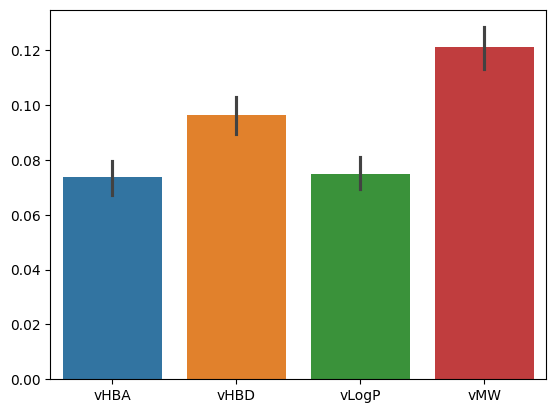

In [55]:
sns.barplot(data=structures[structures["source"]=="drugbank"][["vHBA", "vHBD", "vLogP", "vMW"]])

<Axes: >

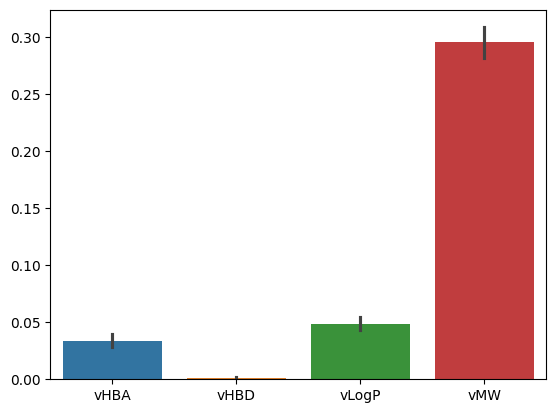

In [57]:
sns.barplot(data=structures[structures["source"]=="chembl"][["vHBA", "vHBD", "vLogP", "vMW"]])

<Axes: >

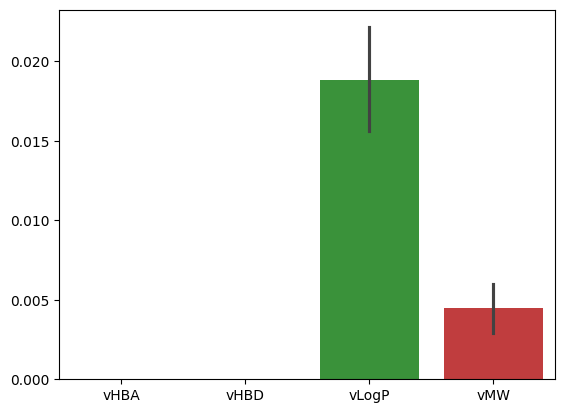

In [58]:
sns.barplot(data=structures[structures["source"]=="zinc"][["vHBA", "vHBD", "vLogP", "vMW"]])

<Axes: xlabel='variable', ylabel='value'>

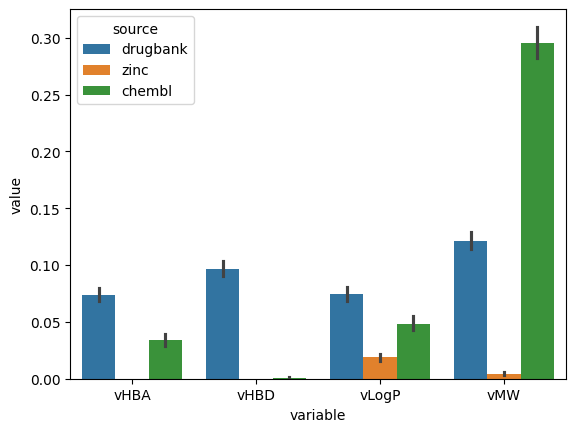

In [63]:
sns.barplot(data=structures.melt(["source"],["vHBA", "vHBD", "vLogP", "vMW"]), x="variable", y="value", hue="source")

<Axes: xlabel='variable', ylabel='value'>

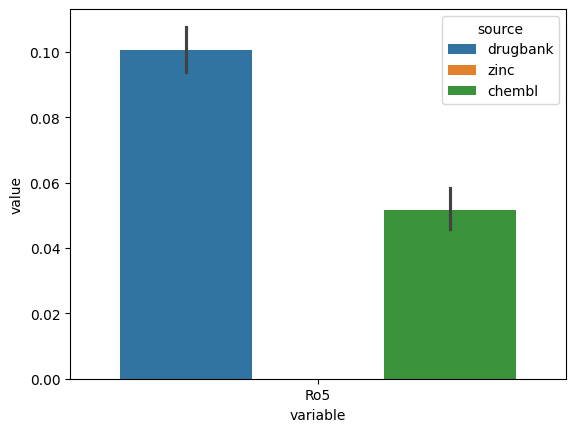

In [67]:
sns.barplot(data=structures.melt(["source"],["Ro5"]), x="variable", y="value", hue="source")

In [70]:
mol=Chem.MolFromSmiles("NCCCCc1ccncc1")

In [88]:
p = Chem.MolFromSmarts("N.n")

In [91]:
structures["hNn"] = structures["mol"].apply(lambda x: x.HasSubstructMatch(p))

In [92]:
structures

,source,mol,HBA,HBD,LogP,MW,SMILES,vHBA,vHBD,vLogP,vMW,Ro5,hNn
id,,,,,,,,,,,,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118CEF...,29,28,-8.11643,2178.985813,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...,True,True,False,True,True,False
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...,16,17,-3.10570,1268.641439,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,True,True,False,True,True,True
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...,15,14,-4.13203,1068.426955,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]1...,True,True,False,True,True,False
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...,16,17,-0.50613,1429.669818,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,True,True,False,True,True,True
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000118D34...,12,5,3.26900,1201.841368,C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...,True,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CHEMBL4287809,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118FF4...,6,1,2.70500,426.079804,COc1ncc(-c2ccc3nccc(=O)n3c2)cc1NS(=O)(=O)c1ccc...,False,False,False,False,False,True
CHEMBL4280265,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118FF4...,5,1,3.48890,448.020845,O=c1ccnc2ccc(-c3cnc(Cl)c(NS(=O)(=O)c4ccc(F)cc4...,False,False,False,False,False,True
CHEMBL4246563,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000118FF4...,4,1,4.92340,407.126991,C=CC(=O)Nc1ccc(-n2c(=O)ccc3oc4ccc(-c5cccnc5)cc...,False,False,False,False,False,True


In [94]:
type(p), type(mol)

(rdkit.Chem.rdchem.Mol, rdkit.Chem.rdchem.Mol)